In [399]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
print(df.head())
print(df.columns)

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [400]:
df.info()
df["Churn"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [401]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [402]:
df["TotalCharges"].dtype

dtype('O')

In [403]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [404]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [405]:
df["TotalCharges"].dtype

dtype('float64')

In [406]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


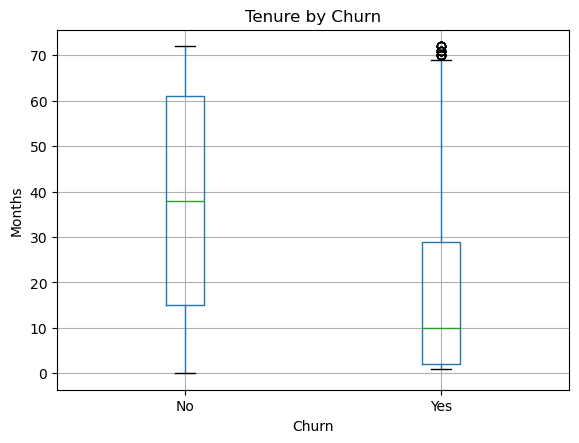

In [407]:
import matplotlib.pyplot as plt

df.boxplot(column="tenure", by="Churn")

plt.title("Tenure by Churn")
plt.suptitle("")
plt.ylabel("Months")
plt.show()

In [408]:
df.groupby("Churn")["Contract"].value_counts(normalize=True)

Churn  Contract      
No     Month-to-month    0.429068
       Two year          0.318322
       One year          0.252609
Yes    Month-to-month    0.885500
       One year          0.088818
       Two year          0.025682
Name: proportion, dtype: float64

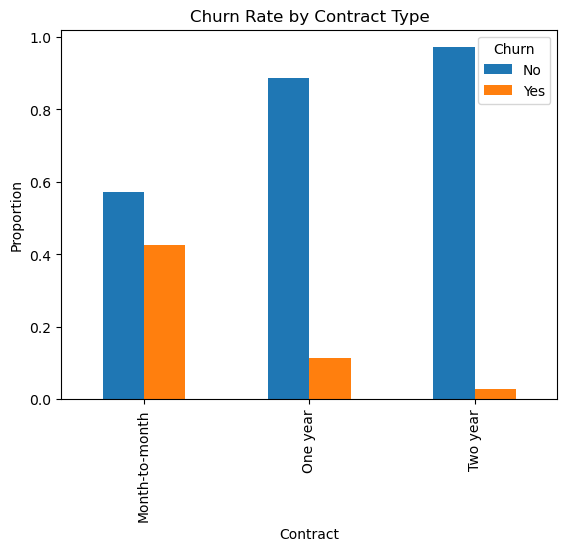

In [409]:
import pandas as pd
import matplotlib.pyplot as plt

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.show()

In [410]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


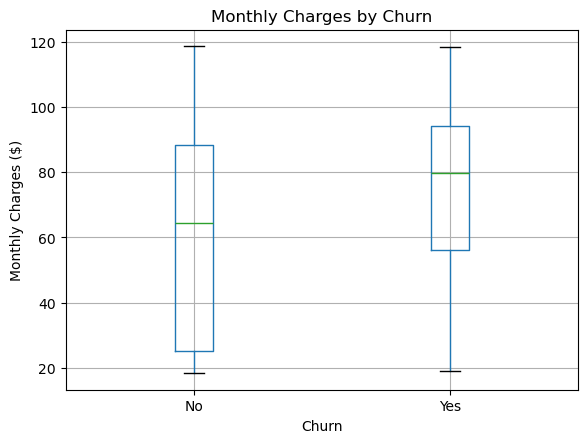

In [411]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.ylabel("Monthly Charges ($)")
plt.show()

In [412]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


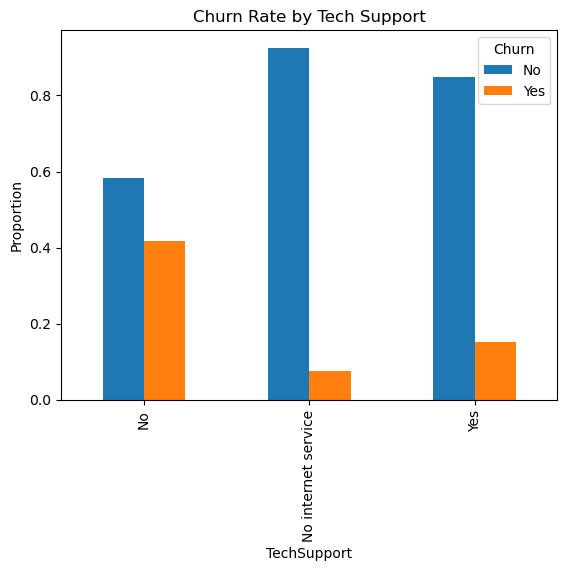

In [413]:
tech_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
)

tech_churn.plot(kind="bar")

plt.title("Churn Rate by Tech Support")
plt.ylabel("Proportion")
plt.show()

In [414]:
for col in [
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "PaymentMethod"
]:
    print("\n", col)
    print(
        pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        )
    )


 InternetService
Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050

 OnlineSecurity
Churn                      No       Yes
OnlineSecurity                         
No                   0.582333  0.417667
No internet service  0.925950  0.074050
Yes                  0.853888  0.146112

 OnlineBackup
Churn                      No       Yes
OnlineBackup                           
No                   0.600712  0.399288
No internet service  0.925950  0.074050
Yes                  0.784685  0.215315

 DeviceProtection
Churn                      No       Yes
DeviceProtection                       
No                   0.608724  0.391276
No internet service  0.925950  0.074050
Yes                  0.774979  0.225021

 PaymentMethod
Churn                            No       Yes
PaymentMethod                                
Bank transfer (automatic)  0.832902  0.1670

In [415]:
model_df = df.copy()

model_df["TotalCharges"] = pd.to_numeric(
    model_df["TotalCharges"],
    errors="coerce"
)

model_df = model_df.dropna()

model_df["Churn"] = model_df["Churn"].map({"No": 0, "Yes": 1})

model_df = model_df.drop("customerID", axis=1)

model_df = pd.get_dummies(model_df, drop_first=True)

X = model_df.drop("Churn", axis=1)
y = model_df["Churn"]

In [416]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [417]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient
10,InternetService_Fiber optic,1.106689
23,StreamingMovies_Yes,0.377300
21,StreamingTV_Yes,0.358999
8,MultipleLines_No phone service,0.341906
9,MultipleLines_Yes,0.286952
26,PaperlessBilling_Yes,0.275783
0,SeniorCitizen,0.261568
28,PaymentMethod_Electronic check,0.259870
5,Partner_Yes,0.050707
17,DeviceProtection_Yes,0.045002


In [418]:
coef_df.tail(15)

,Feature,Coefficient
1,tenure,-0.061352
29,PaymentMethod_Mailed check,-0.072843
27,PaymentMethod_Credit card (automatic),-0.140133
16,DeviceProtection_No internet service,-0.154180
14,OnlineBackup_No internet service,-0.154180
18,TechSupport_No internet service,-0.154180
20,StreamingTV_No internet service,-0.154180
22,StreamingMovies_No internet service,-0.154180
12,OnlineSecurity_No internet service,-0.154180
11,InternetService_No,-0.154180


In [419]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

print(cm)

[[915 118]
 [182 192]]


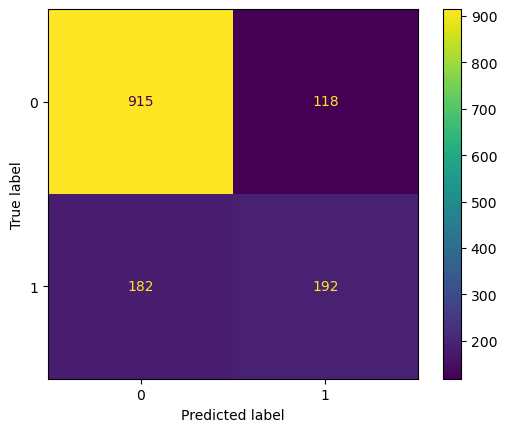

In [420]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm).plot()
plt.show()

In [421]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, probs))

ROC-AUC: 0.8320814200889368


In [422]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, probs))

ROC-AUC: 0.8320814200889368


In [423]:
from sklearn.metrics import classification_report

preds_03 = (probs >= 0.3).astype(int)

print(classification_report(y_test, preds_03))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.77      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.77      1407



In [424]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

tree_preds = tree.predict(X_test)
tree_probs = tree.predict_proba(X_test)[:, 1]

print(classification_report(y_test, tree_preds))
print("ROC-AUC:", roc_auc_score(y_test, tree_probs))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.48      0.52      0.50       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.72      0.73      1407

ROC-AUC: 0.6616546997220081


In [425]:
tree2 = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree2.fit(X_train, y_train)

preds2 = tree2.predict(X_test)
probs2 = tree2.predict_proba(X_test)[:,1]

print(classification_report(y_test, preds2))
print("ROC-AUC:", roc_auc_score(y_test, probs2))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.53      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.78      0.78      1407

ROC-AUC: 0.8125663272437373


In [426]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8189518613042329


In [427]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LogisticRegression(max_iter=5000),
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print("Mean ROC-AUC:", scores.mean())
print("Std Dev:", scores.std())

[0.85751226 0.85898763 0.83470799 0.83625586 0.83865761]
Mean ROC-AUC: 0.8452242681286867
Std Dev: 0.010719798934874519


In [428]:
from sklearn.compose import make_column_selector

numeric_selector = make_column_selector(dtype_include=["int64", "float64"])
categorical_selector = make_column_selector(dtype_include=["object"])

print("Numeric:")
print(numeric_selector(X))

print("\nCategorical:")
print(categorical_selector(X))

Numeric:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical:
[]


In [429]:
import os

print(os.path.expanduser("~"))

C:\Users\satwi


In [430]:
raw_df = df.copy()

raw_df["TotalCharges"] = pd.to_numeric(
    raw_df["TotalCharges"],
    errors="coerce"
)

raw_df = raw_df.dropna()

raw_df["Churn"] = raw_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

raw_df = raw_df.drop("customerID", axis=1)

X = raw_df.drop("Churn", axis=1)
y = raw_df["Churn"]

In [431]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_selector(X)
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_selector(X)
        )
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [432]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=5000))
    ]
)

pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [433]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [434]:
from sklearn.metrics import classification_report, roc_auc_score

pipeline_preds = pipeline.predict(X_test)
pipeline_probs = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pipeline_preds))
print("ROC-AUC:", roc_auc_score(y_test, pipeline_probs))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8319778848792002


In [435]:
new_customer = pd.DataFrame({
    "gender": ["Male"],
    "SeniorCitizen": [0],
    "Partner": ["No"],
    "Dependents": ["No"],
    "tenure": [2],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [89.5],
    "TotalCharges": [179.0]
})


new_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.5,179.0


In [436]:
prediction = pipeline.predict(new_customer)
probability = pipeline.predict_proba(new_customer)

print("Prediction:", prediction)
print("Probability [No Churn, Churn]:")
print(probability)

Prediction: [1]
Probability [No Churn, Churn]:
[[0.22266637 0.77733363]]


In [437]:
import joblib

joblib.dump(pipeline, "churn_pipeline.pkl")

['churn_pipeline.pkl']

In [438]:
loaded_pipeline = joblib.load("churn_pipeline.pkl")

loaded_pipeline.predict(new_customer)

array([1])

In [439]:
import os

print(os.getcwd())

C:\Users\satwi


In [440]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

param_grid = {
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10]
}

grid = GridSearchCV(
    tree_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc"
)

grid.fit(X_train, y_train)

print("Best depth:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Best depth: {'model__max_depth': 4}
Best CV ROC-AUC: 0.8335889607812967


In [441]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [4, 6, 8, None]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV ROC-AUC:", rf_grid.best_score_)

Best Parameters: {'model__max_depth': 8, 'model__n_estimators': 200}
Best CV ROC-AUC: 0.8495367933466682


In [442]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [443]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

xgb_pipeline.fit(X_train, y_train)

xgb_preds = xgb_pipeline.predict(X_test)
xgb_probs = xgb_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.58      0.48      0.52       374

    accuracy                           0.77      1407
   macro avg       0.70      0.68      0.69      1407
weighted avg       0.76      0.77      0.76      1407

ROC-AUC: 0.807973246501804


In [444]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__scale_pos_weight": [
        1,
        scale_pos_weight,
        2,
        3
    ]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print("Best CV ROC-AUC:", xgb_grid.best_score_)

Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': np.float64(2.762541806020067)}
Best CV ROC-AUC: 0.8515803282936666


In [445]:
best_xgb = xgb_grid.best_estimator_

best_xgb_preds = best_xgb.predict(X_test)
best_xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, best_xgb_preds))
print("Test ROC-AUC:", roc_auc_score(y_test, best_xgb_probs))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407

Test ROC-AUC: 0.8350101723343566


In [446]:
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

In [447]:
from sklearn.metrics import classification_report

thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    preds = (xgb_probs >= t).astype(int)

    print(f"\nThreshold = {t}")
    print(classification_report(y_test, preds))


Threshold = 0.5
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407


Threshold = 0.4
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      1033
           1       0.46      0.87      0.60       374

    accuracy                           0.69      1407
   macro avg       0.69      0.75      0.67      1407
weighted avg       0.80      0.69      0.71      1407


Threshold = 0.3
              precision    recall  f1-score   support

           0       0.95      0.54      0.69      1033
           1       0.42      0.92      0.57       374

    accuracy                           0.64      1407
   macro avg       0.68      0.73      0.63      1407
weighted avg       0.81

In [448]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.05, 1.00, 0.01)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    preds = (xgb_probs >= t).astype(int)
    score = f1_score(y_test, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best Threshold:", round(best_threshold, 2))
print("Best F1:", round(best_f1, 3))

Best Threshold: 0.56
Best F1: 0.623


In [449]:
preds = (xgb_probs >= best_threshold).astype(int)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1033
           1       0.54      0.74      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



In [450]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

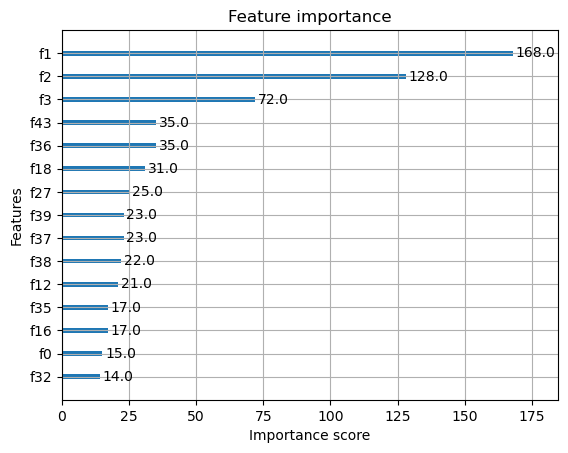

In [451]:
model = best_xgb.named_steps["model"]

plot_importance(
    model,
    max_num_features=15
)

plt.show()

In [452]:
feature_names = best_xgb.named_steps[
    "preprocessor"
].get_feature_names_out()

print(feature_names)

['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service'
 'cat__OnlineSecurity_Yes' 'cat__OnlineBackup_No'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No' 'cat__DeviceProtection_No internet service'
 'cat__DeviceProtection_Yes' 'cat__TechSupport_No'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No' 'cat__StreamingTV_No internet service'
 'cat__StreamingTV_Yes' 'cat__StreamingMovies_No'
 'cat__StreamingMovies_No internet service' 'cat__StreamingMovies_Yes'
 'cat__Contract_Month-

In [453]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
36,cat__Contract_Month-to-month,0.434105
16,cat__InternetService_Fiber optic,0.107768
18,cat__OnlineSecurity_No,0.072540
27,cat__TechSupport_No,0.065486
15,cat__InternetService_DSL,0.032412
35,cat__StreamingMovies_Yes,0.026662
1,num__tenure,0.024840
43,cat__PaymentMethod_Electronic check,0.024659
38,cat__Contract_Two year,0.022799
37,cat__Contract_One year,0.022484


In [454]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [455]:
import shap

preprocessor = best_xgb.named_steps["preprocessor"]
model = best_xgb.named_steps["model"]

X_test_transformed = preprocessor.transform(X_test)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_transformed)

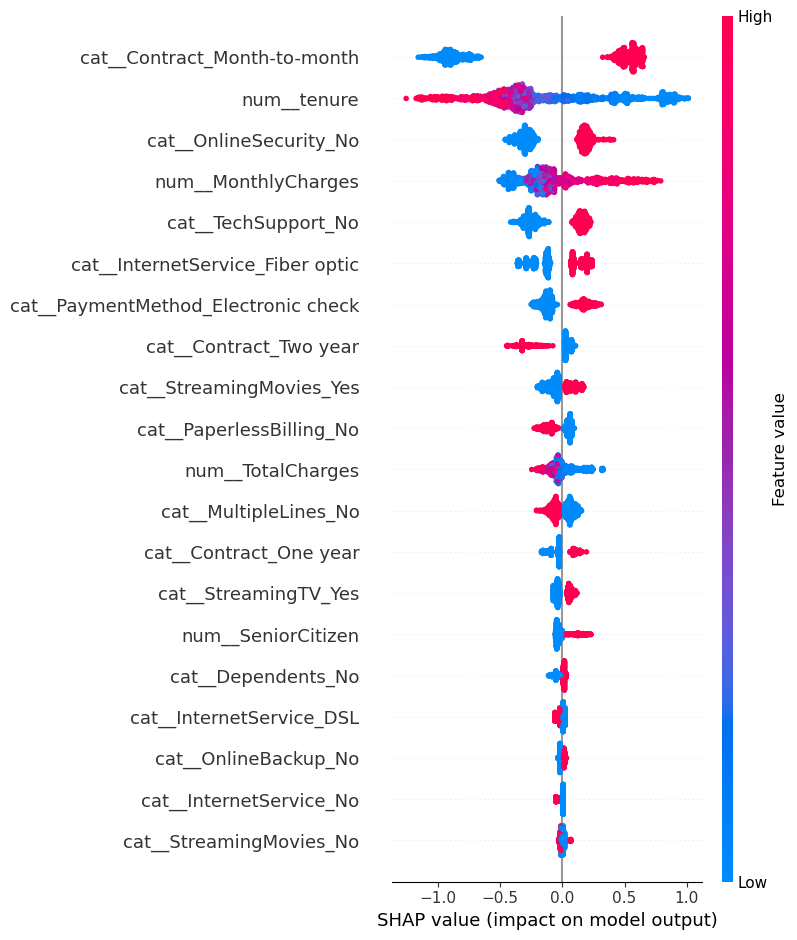

In [456]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [457]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(scale_pos_weight)

2.762541806020067


In [458]:
best_xgb = xgb_grid.best_estimator_

best_xgb_preds = best_xgb.predict(X_test)
best_xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, best_xgb_preds))
print("Test ROC-AUC:", roc_auc_score(y_test, best_xgb_probs))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407

Test ROC-AUC: 0.8350101723343566


In [459]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.05, 1.00, 0.01)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    preds = (best_xgb_probs >= t).astype(int)
    score = f1_score(y_test, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best Threshold:", round(best_threshold, 2))
print("Best F1:", round(best_f1, 3))

Best Threshold: 0.56
Best F1: 0.623


In [460]:
final_preds = (best_xgb_probs >= best_threshold).astype(int)

print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1033
           1       0.54      0.74      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



In [461]:
joblib.dump(best_xgb, "churn_pipeline.pkl")

['churn_pipeline.pkl']

In [462]:
model = best_xgb.named_steps["model"]

print(model.get_params()["learning_rate"])
print(model.get_params()["max_depth"])
print(model.get_params()["n_estimators"])
print(model.get_params()["scale_pos_weight"])

0.05
3
100
2.762541806020067


In [463]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
import joblib

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            learning_rate=0.05,
            max_depth=2,
            n_estimators=200,
            scale_pos_weight=1
        ))
    ]
)

final_pipeline.fit(X_train, y_train)

final_preds = final_pipeline.predict(X_test)
final_probs = final_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, final_preds))
print("Test ROC-AUC:", roc_auc_score(y_test, final_probs))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Test ROC-AUC: 0.8358811622862645


In [464]:
model = final_pipeline.named_steps["model"]

print(model.get_params()["learning_rate"])
print(model.get_params()["max_depth"])
print(model.get_params()["n_estimators"])
print(model.get_params()["scale_pos_weight"])

0.05
2
200
1


In [466]:
joblib.dump(final_pipeline, "churn_pipeline.pkl")

['churn_pipeline.pkl']

In [467]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\satwi
['.anaconda', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'archive.zip', 'churn_pipeline.pkl', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{d2df26bc-75bb-11f0-9fd9-ba1a61926249}.TM.blf', 'NTUSER.DAT{d2df26bc-75bb-11f0-9fd9-ba1a61926249}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{d2df26bc-75bb-11f0-9fd9-ba1a61926249}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Satwik-050626.ipynb', 'SatwikChurnProject062426.ipynb', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled1.ipynb', 'Utils.py.txt', 'Videos', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']
